In [3]:
# ── Diabetes Risk Predictor — Lasso Regression ────────────────────────────────
# Goal: Predict diabetes risk score AND discover which health indicators matter
# Dataset: BRFSS 2015 — 250k rows, 21 health features
# Key insight: Lasso = automatic feature selection (clinical interpretability)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, LassoCV, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                               r2_score, roc_auc_score, classification_report)
import scipy.stats as stats

In [4]:
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

print(f"Dataset shape   : {df.shape}")
print(f"Diabetic cases  : {df['Diabetes_binary'].sum():.0f} ({df['Diabetes_binary'].mean()*100:.1f}%)")
print(f"Healthy cases   : {(1-df['Diabetes_binary']).sum():.0f} ({(1-df['Diabetes_binary'].mean())*100:.1f}%)")
print(f"Missing values  : {df.isnull().sum().sum()}")
print("\n── All 21 features ──")
print(df.columns.tolist())
print("\n── Feature stats ──")
df.describe().round(2)

Dataset shape   : (253680, 22)
Diabetic cases  : 35346 (13.9%)
Healthy cases   : 218334 (86.1%)
Missing values  : 0

── All 21 features ──
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

── Feature stats ──


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,...,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.14,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,...,0.95,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05
std,0.35,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,...,0.22,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07
min,0.00,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00
50%,0.00,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00
75%,0.00,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,...,1.00,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00
max,1.00,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00


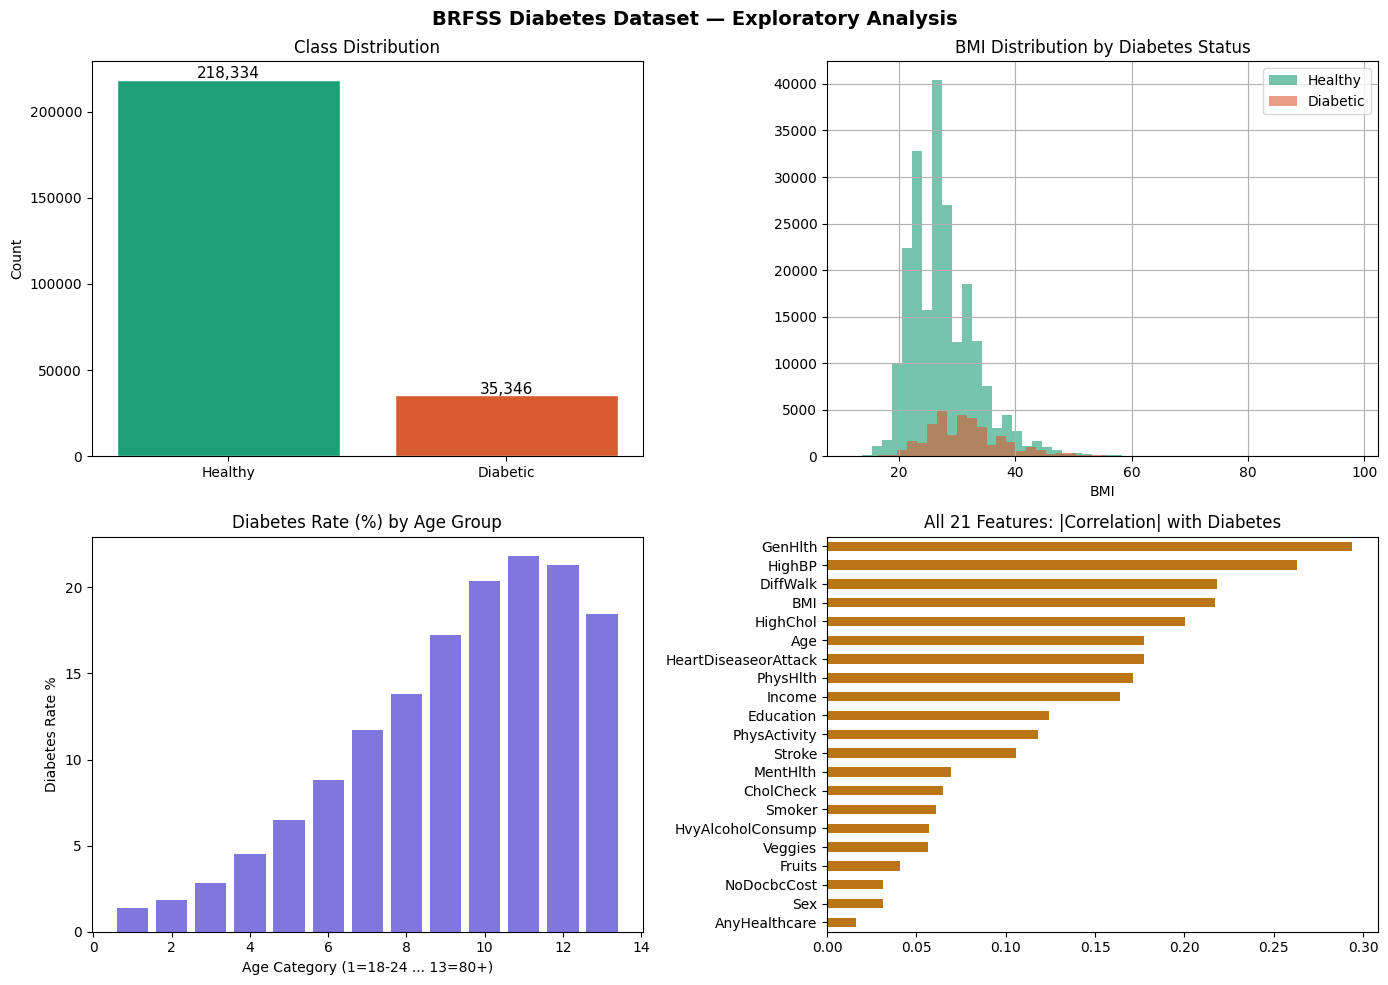

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('BRFSS Diabetes Dataset — Exploratory Analysis', fontsize=14, fontweight='bold')

# 1. Class balance
counts = df['Diabetes_binary'].value_counts()
axes[0,0].bar(['Healthy', 'Diabetic'], counts.values,
              color=['#1D9E75', '#D85A30'], edgecolor='white')
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

# 2. BMI distribution by class
df[df['Diabetes_binary']==0]['BMI'].hist(bins=50, ax=axes[0,1],
    alpha=0.6, color='#1D9E75', label='Healthy')
df[df['Diabetes_binary']==1]['BMI'].hist(bins=50, ax=axes[0,1],
    alpha=0.6, color='#D85A30', label='Diabetic')
axes[0,1].set_title('BMI Distribution by Diabetes Status')
axes[0,1].legend(); axes[0,1].set_xlabel('BMI')

# 3. Age vs diabetes rate
age_rate = df.groupby('Age')['Diabetes_binary'].mean() * 100
axes[1,0].bar(age_rate.index, age_rate.values, color='#7F77DD')
axes[1,0].set_title('Diabetes Rate (%) by Age Group')
axes[1,0].set_xlabel('Age Category (1=18-24 ... 13=80+)')
axes[1,0].set_ylabel('Diabetes Rate %')

# 4. Feature correlations with target
corr = df.corr()['Diabetes_binary'].drop('Diabetes_binary').abs().sort_values(ascending=False)
corr.plot(kind='barh', ax=axes[1,1], color='#BA7517')
axes[1,1].set_title('All 21 Features: |Correlation| with Diabetes')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('01_eda.png', bbox_inches='tight')
plt.show()

In [7]:
# ── Domain-specific interaction features ─────────────────────────────────────
df['BMI_Age']          = df['BMI'] * df['Age']          # compound risk
df['HighBP_HighChol']  = df['HighBP'] * df['HighChol']  # metabolic syndrome
df['Unhealthy_lifestyle'] = (
    (df['Smoker'] + df['HvyAlcoholConsump'] + (df['PhysActivity']==0).astype(int))
)

# ── BMI categories (clinical standard) ───────────────────────────────────────
df['BMI_Obese']      = (df['BMI'] >= 30).astype(int)
df['BMI_Overweight'] = ((df['BMI'] >= 25) & (df['BMI'] < 30)).astype(int)

# ── Feature set — all 21 original + 5 engineered ─────────────────────────────
original_features = [c for c in df.columns if c != 'Diabetes_binary'
                     and c not in ['BMI_Age','HighBP_HighChol',
                                     'Unhealthy_lifestyle','BMI_Obese','BMI_Overweight']]
engineered = ['BMI_Age', 'HighBP_HighChol', 'Unhealthy_lifestyle',
              'BMI_Obese', 'BMI_Overweight']
features = original_features + engineered
target   = 'Diabetes_binary'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Total features  : {len(features)} ({len(original_features)} original + {len(engineered)} engineered)")
print(f"Train samples   : {X_train.shape[0]:,}")
print(f"Test samples    : {X_test.shape[0]:,}")

Total features  : 26 (21 original + 5 engineered)
Train samples   : 202,944
Test samples    : 50,736


In [8]:
# ── LassoCV finds best alpha automatically via cross-validation ───────────────
lasso_cv = LassoCV(
    alphas=np.logspace(-4, 1, 100),
    cv=5,
    max_iter=10000,
    random_state=42
)
lasso_cv.fit(X_train_sc, y_train)

best_alpha = lasso_cv.alpha_
print(f"Best alpha found by LassoCV : {best_alpha:.6f}")

# Count surviving features (coeff != 0)
surviving = np.sum(lasso_cv.coef_ != 0)
zeroed    = np.sum(lasso_cv.coef_ == 0)
print(f"Features KEPT (coeff ≠ 0)  : {surviving} out of {len(features)}")
print(f"Features ZEROED (coeff = 0) : {zeroed}")
print("\nThis is Lasso's automatic feature selection in action!")

Best alpha found by LassoCV : 0.000100
Features KEPT (coeff ≠ 0)  : 24 out of 26
Features ZEROED (coeff = 0) : 2

This is Lasso's automatic feature selection in action!


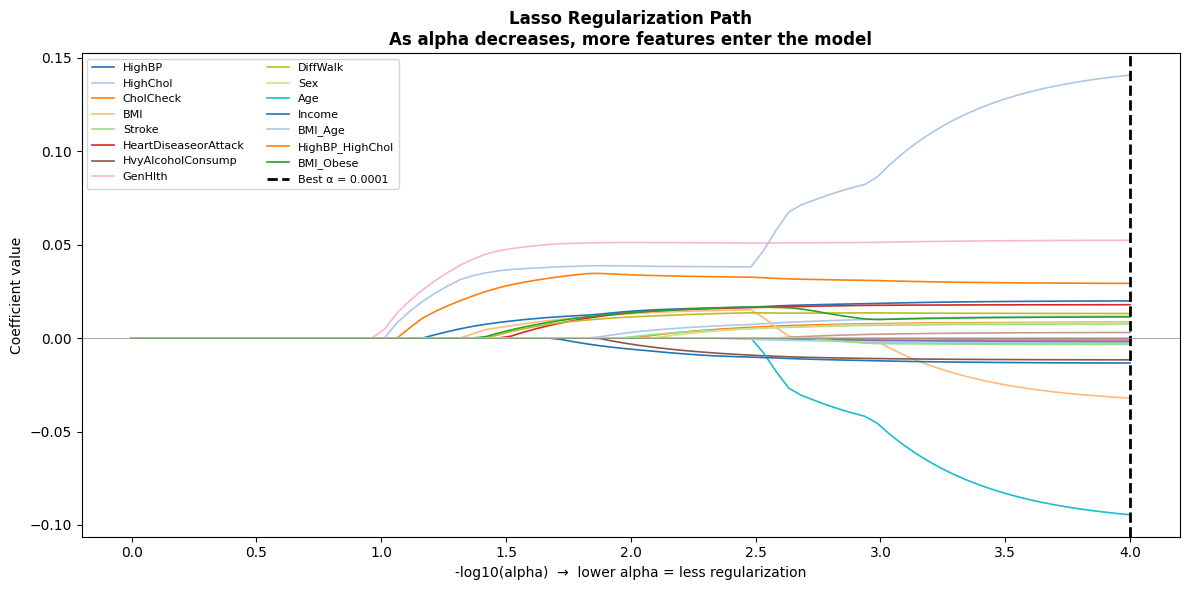

In [10]:
# ── Regularization path: shows HOW Lasso zeros features as alpha increases ───
# This is the most impressive plot in any Lasso project

from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(
    X_train_sc, y_train,
    alphas=np.logspace(-4, 0, 80),
    max_iter=10000
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab20.colors

for i in range(coefs_path.shape[0]):
    ax.plot(-np.log10(alphas_path), coefs_path[i],
            color=colors[i % 20], linewidth=1.2,
            label=features[i] if np.abs(coefs_path[i]).max() > 0.005 else '_')

ax.axvline(-np.log10(best_alpha), color='black', linestyle='--',
           linewidth=2, label=f'Best α = {best_alpha:.4f}')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('-log10(alpha)  →  lower alpha = less regularization')
ax.set_ylabel('Coefficient value')
ax.set_title('Lasso Regularization Path\nAs alpha decreases, more features enter the model',
             fontweight='bold')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('02_regularization_path.png', bbox_inches='tight')
plt.show()

═══════════════════════════════════════════════════════
 LASSO FEATURE SELECTION RESULTS
═══════════════════════════════════════════════════════

✓ SELECTED (24 features — clinical markers that matter):
   BMI_Age                         +0.1407  ↑ increases risk
   GenHlth                         +0.0523  ↑ increases risk
   HighBP_HighChol                 +0.0292  ↑ increases risk
   HighBP                          +0.0199  ↑ increases risk
   HeartDiseaseorAttack            +0.0178  ↑ increases risk
   DiffWalk                        +0.0131  ↑ increases risk
   HighChol                        +0.0117  ↑ increases risk
   BMI_Obese                       +0.0113  ↑ increases risk
   CholCheck                       +0.0085  ↑ increases risk
   Sex                             +0.0082  ↑ increases risk
   Stroke                          +0.0075  ↑ increases risk
   AnyHealthcare                   +0.0030  ↑ increases risk
   Veggies                         -0.0002  ↓ decreases risk
   N

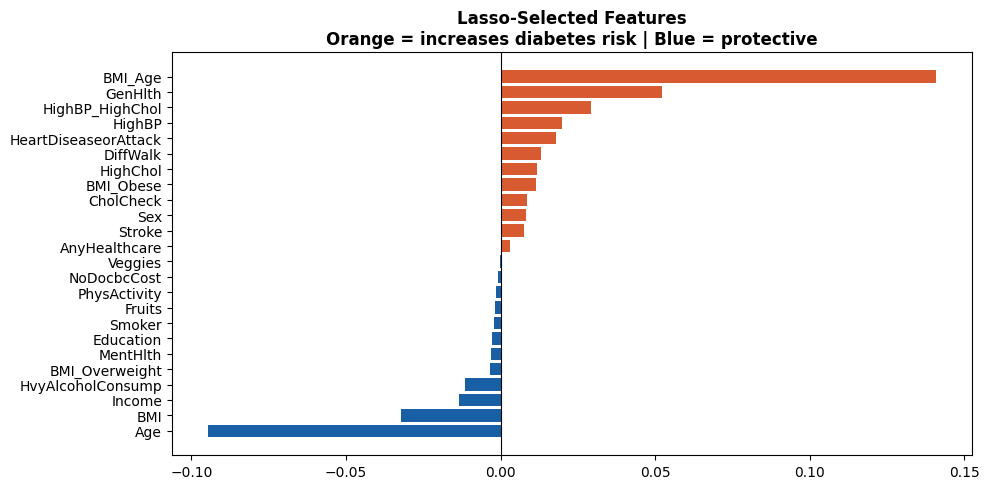

In [11]:
# ── Which features survived? This IS the clinical insight ─────────────────────
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lasso_cv.coef_
})
surviving_df = coeff_df[coeff_df['Coefficient'] != 0].sort_values('Coefficient')
zeroed_df    = coeff_df[coeff_df['Coefficient'] == 0]

print("═" * 55)
print(" LASSO FEATURE SELECTION RESULTS")
print("═" * 55)
print(f"\n✓ SELECTED ({len(surviving_df)} features — clinical markers that matter):")
for _, row in surviving_df.sort_values('Coefficient', ascending=False).iterrows():
    direction = "↑ increases risk" if row['Coefficient'] > 0 else "↓ decreases risk"
    print(f"   {row['Feature']:30s}  {row['Coefficient']:+.4f}  {direction}")
print(f"\n✗ ZEROED OUT ({len(zeroed_df)} features — Lasso says irrelevant):")
print(f"   {', '.join(zeroed_df['Feature'].tolist())}")

# Surviving features bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#D85A30' if c > 0 else '#185FA5' for c in surviving_df['Coefficient']]
ax.barh(surviving_df['Feature'], surviving_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Lasso-Selected Features\nOrange = increases diabetes risk | Blue = protective',
             fontweight='bold')
plt.tight_layout()
plt.savefig('03_selected_features.png', bbox_inches='tight')
plt.show()

In [12]:
y_pred_lasso = lasso_cv.predict(X_test_sc)
y_pred_binary = (y_pred_lasso >= 0.5).astype(int)

# Train Ridge for comparison
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)
ridge_nonzero = np.sum(ridge.coef_ != 0)

print("═" * 52)
print("  LASSO vs RIDGE — Feature Selection Showdown")
print("═" * 52)
print(f"  {'Metric':<20} {'Lasso':>12} {'Ridge':>12}")
print(f"  {'-'*44}")
print(f"  {'Features used':<20} {np.sum(lasso_cv.coef_!=0):>12} {ridge_nonzero:>12}")
print(f"  {'R²':<20} {r2_score(y_test,y_pred_lasso):>12.4f} {r2_score(y_test,y_pred_ridge):>12.4f}")
print(f"  {'MAE':<20} {mean_absolute_error(y_test,y_pred_lasso):>12.4f} {mean_absolute_error(y_test,y_pred_ridge):>12.4f}")
print(f"  {'RMSE':<20} {np.sqrt(mean_squared_error(y_test,y_pred_lasso)):>12.4f} {np.sqrt(mean_squared_error(y_test,y_pred_ridge)):>12.4f}")
print("═" * 52)
print("\nKey insight: Lasso uses fewer features for similar performance.")
print("In clinical settings, fewer features = easier to collect = more practical.")

print("\n── Classification Report (Lasso, threshold=0.5) ──")
print(classification_report(y_test, y_pred_binary, target_names=['Healthy', 'Diabetic']))

════════════════════════════════════════════════════
  LASSO vs RIDGE — Feature Selection Showdown
════════════════════════════════════════════════════
  Metric                      Lasso        Ridge
  --------------------------------------------
  Features used                  24           26
  R²                         0.1648       0.1647
  MAE                        0.2111       0.2110
  RMSE                       0.3165       0.3165
════════════════════════════════════════════════════

Key insight: Lasso uses fewer features for similar performance.
In clinical settings, fewer features = easier to collect = more practical.

── Classification Report (Lasso, threshold=0.5) ──
              precision    recall  f1-score   support

     Healthy       0.87      0.99      0.93     43667
    Diabetic       0.58      0.07      0.12      7069

    accuracy                           0.86     50736
   macro avg       0.72      0.53      0.52     50736
weighted avg       0.83      0.86      

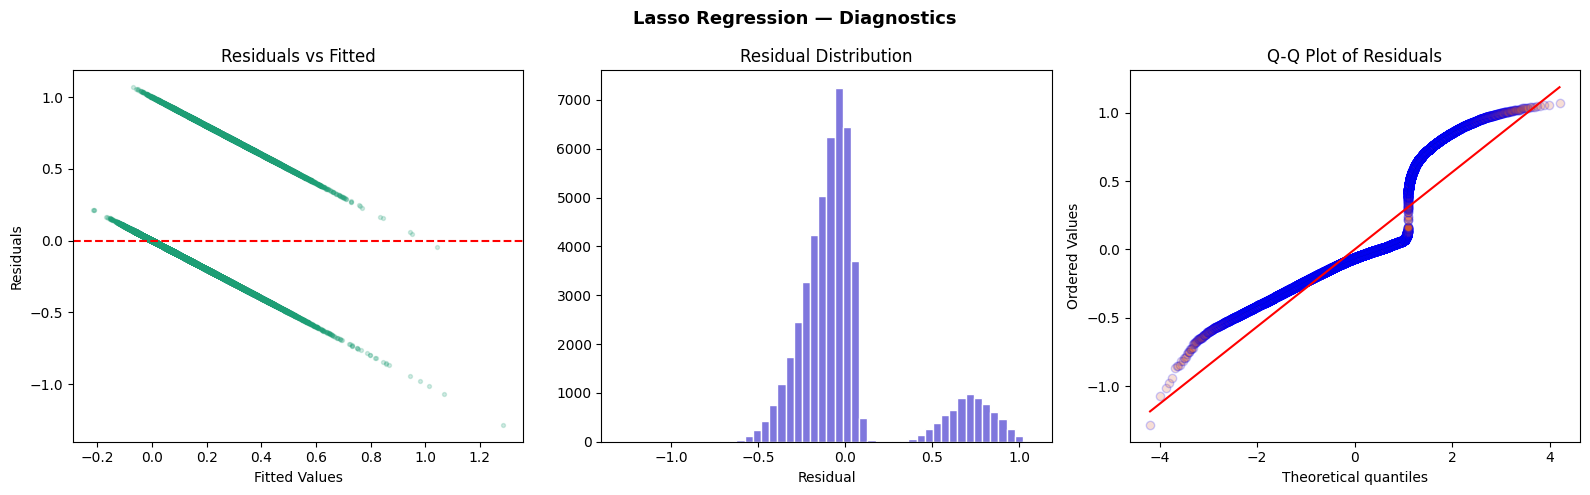

In [14]:
residuals = y_test - y_pred_lasso

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Lasso Regression — Diagnostics', fontsize=13, fontweight='bold')

# Residuals vs Fitted
axes[0].scatter(y_pred_lasso, residuals, alpha=0.2, color='#1D9E75', s=8)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values'); axes[0].set_ylabel('Residuals')

# Residual histogram
axes[1].hist(residuals, bins=50, color='#7F77DD', edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

# Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')
axes[2].get_lines()[0].set_markerfacecolor('#D85A30')
axes[2].get_lines()[0].set_alpha(0.2)

plt.tight_layout()
plt.savefig('04_diagnostics.png', bbox_inches='tight')
plt.show()

In [15]:
# ── Predict diabetes risk for a custom patient profile ────────────────────────
# Edit these values to simulate different patient archetypes

patient = {
    'HighBP': 1, 'HighChol': 1, 'CholCheck': 1,
    'BMI': 32, 'Smoker': 0, 'Stroke': 0,
    'HeartDiseaseorAttack': 0, 'PhysActivity': 1,
    'Fruits': 1, 'Veggies': 1, 'HvyAlcoholConsump': 0,
    'AnyHealthcare': 1, 'NoDocbcCost': 0, 'GenHlth': 3,
    'MentHlth': 2, 'PhysHlth': 3, 'DiffWalk': 0,
    'Sex': 1, 'Age': 9, 'Education': 5, 'Income': 6,
    # engineered features
    'BMI_Age': 32 * 9,
    'HighBP_HighChol': 1 * 1,
    'Unhealthy_lifestyle': 0,
    'BMI_Obese': 1,
    'BMI_Overweight': 0
}

p_df = pd.DataFrame([patient])
p_sc  = scaler.transform(p_df[features])
risk_score = lasso_cv.predict(p_sc)[0]
risk_pct   = max(0, min(1, risk_score)) * 100

risk_label = "HIGH RISK" if risk_score >= 0.5 else "LOW RISK"

print("╔══════════════════════════════════════════╗")
print("║    PATIENT DIABETES RISK ASSESSMENT      ║")
print("╠══════════════════════════════════════════╣")
print(f"║  Risk Score  : {risk_score:.4f}                  ║")
print(f"║  Risk %      : {risk_pct:.1f}%                     ║")
print(f"║  Assessment  : {risk_label:<26} ║")
print(f"║  BMI         : {patient['BMI']} (Obese)               ║")
print(f"║  High BP     : {'Yes' if patient['HighBP'] else 'No':<26} ║")
print("╚══════════════════════════════════════════╝")
print("\nTip: Change 'HighBP', 'BMI', 'Age' to see how risk changes!")
print("     Lasso only uses the selected features — zeros are ignored.")

╔══════════════════════════════════════════╗
║    PATIENT DIABETES RISK ASSESSMENT      ║
╠══════════════════════════════════════════╣
║  Risk Score  : 0.3096                  ║
║  Risk %      : 31.0%                     ║
║  Assessment  : LOW RISK                   ║
║  BMI         : 32 (Obese)               ║
║  High BP     : Yes                        ║
╚══════════════════════════════════════════╝

Tip: Change 'HighBP', 'BMI', 'Age' to see how risk changes!
     Lasso only uses the selected features — zeros are ignored.
